# NF-Injections Conditional

Learn the density of parameters in GWTC-4 data, conditioned on some detection probability (FAR).

### Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit, logsumexp
from scipy.interpolate import interp1d

from astropy.cosmology import FlatLambdaCDM, z_at_value
import astropy.constants as constants
import astropy.units as u

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut


import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
jax.config.update('jax_enable_x64', True)

In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: usm-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Thu Feb 12 21:02:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:06:00.0 Off |                    0 |
| N/A   48C    P0            100W /  400W |   73265MiB /  95830MiB |      0%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

In [4]:
# load injection data
def read_data(file: str, gwtc_version: int) -> pd.DataFrame:
    # Load
    raw_injection_data = h5py.File(file, 'r')
    # injections now called events in gwtc4
    if gwtc_version == 3:
        events = raw_injection_data['injections']
        m1_key, m2_key, dist_key, redshift_key = "mass1", "mass2", "distance", "redshift"
    elif gwtc_version == 4:
        events = raw_injection_data["events"]
        m1_key, m2_key, dist_key, redshift_key = "mass1_detector", "mass2_detector", "luminosity_distance", "z"
    print("Data length:", len(events))

    # Read injection parameters
    injectionData = pd.DataFrame()
    injectionData['m1_detector'] = np.array(events[m1_key][()], dtype='float64')
    injectionData['m2_detector'] = np.array(events[m2_key][()], dtype='float64')
    injectionData['luminosity_distance'] = events[dist_key][()]/1000.  # Convert from Mpc to Gpc
    injectionData['cos_inclination'] = np.cos(events['inclination'])
    injectionData['right_ascension'] = events['right_ascension']
    injectionData['cos_right_ascension'] = np.cos(events['right_ascension'])
    injectionData['declination'] = events['declination']
    injectionData['polarization'] = events['polarization']
    injectionData['cos_polarization'] = np.cos(events['polarization'])
    injectionData['redshift'] = events[redshift_key][()]

    # add source-frame quantities
    injectionData["m1_source"] = injectionData['m1_detector'] / (1 + injectionData['redshift'])
    injectionData["m2_source"] = injectionData['m2_detector'] / (1 + injectionData['redshift'])
    
    # Some derived mass parameters
    injectionData['q'] = injectionData.m2_detector/injectionData.m1_detector
    injectionData['eta'] = injectionData.m1_detector*injectionData.m2_detector/(injectionData.m1_detector+injectionData.m2_detector)**2
    injectionData['chirp_mass_detector'] = injectionData.eta**(3./5.)*(injectionData.m1_detector+injectionData.m2_detector)
    injectionData['total_mass_detector'] = (injectionData.m1_detector+injectionData.m2_detector)

    # And some derived spin parameters
    s1x = np.array(events['spin1x'])
    s1y = np.array(events['spin1y'])
    s1z = np.array(events['spin1z'])
    s2x = np.array(events['spin2x'])
    s2y = np.array(events['spin2y'])
    s2z = np.array(events['spin2z'])
    injectionData['s1x'] = s1x
    injectionData['s1y'] = s1y
    injectionData['s1z'] = s1z
    injectionData['s2x'] = s2x
    injectionData['s2y'] = s2y
    injectionData['s2z'] = s2z
    injectionData['a1'] = np.sqrt(s1x**2 + s1y**2 + s1z**2)
    injectionData['a2'] = np.sqrt(s2x**2 + s2y**2 + s2z**2)
    injectionData['cost1'] = s1z/injectionData.a1
    injectionData['cost2'] = s2z/injectionData.a2
    injectionData['Xeff'] = (s1z + injectionData.q*s2z)/(1.+injectionData.q)
    injectionData['Xdiff'] = (s1z - injectionData.q*s2z)/(1.+injectionData.q)

    sint1 = np.sqrt(1-injectionData.cost1**2)
    sint2 = np.sqrt(1-injectionData.cost2**2)

    injectionData['cos_phi1'] = (s1x / (injectionData.a1*sint1))
    injectionData['cos_phi2'] = (s2x / (injectionData.a2*sint2))

    injectionData["phi1"] = np.arccos(injectionData['cos_phi1'])
    injectionData["phi2"] = np.arccos(injectionData['cos_phi2'])
    # injectionData['Xp_gen'] = generalized_Xp(s1x, s1y, s2x,  s2y, injectionData.q)

    # transforming data for NF (making it nearly Gaussian or similarly well distributed)
    injectionData['sinusoidal_right_ascension'] = np.arccos(1 - injectionData.right_ascension / np.pi)
    injectionData['sinusoidal_polarization'] = np.arccos(1 - 2*injectionData.polarization / np.pi)

    injectionData["t1"] = np.arccos(injectionData.cost1)
    injectionData["t2"] = np.arccos(injectionData.cost2)

    # injectionData["sinusoidal_phi1"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi1) / np.pi)
    # injectionData["sinusoidal_phi2"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi2) / np.pi)
    
    if gwtc_version == 4:
        #changed in GWTC4
        far_min = np.min([events['%s_far'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)

        """injectionData['p_draw'] = np.exp(raw_injection_data['lnpdraw_mass1_source_mass2_source_redshift_spin1x_spin1y_spin1z_spin2x_spin2y_spin2z'][:])/(1+injectionData['redshift'])**2/ddL_of_z(injectionData['redshift'],injectionData['luminosity_distance'],H0cosmo)
        T = (raw_injection_data.attrs['total_analysis_time'])/(3600.0*24.0*365.25) 
        injectionData['p_draw'] /= T
        
        
        injectionData['p_draw'] /= injectionData['weights'] # ädont think i should do this here"""

    injectionData['weights'] = events['weights'][()]
    injectionData['far_min'] = far_min
    injectionData['detected'] = np.where(far_min < 1, 1, 0)
    print("Number of detected injections:", np.sum(injectionData['detected']))

    return injectionData

### Load File

In [5]:
# fname = Path("/hildafs/home/jgassert/hildafs_phy220048p_symlink/share/GWTC-PESamples/posterior_samples/O4/GWTC-4_bbh_posterior_samples_seed1.h5")
# fname = Path("/project/ls-gruen/users/julius.gassert/data/GWTC-4_bbh_posterior_samples_seed1.h5")
fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")

# col_names = ['a1', 'a2', 'chieff', 'dL', 'dec', 'm1det', 'm2det', 'ra', 'z']

f = h5py.File(fname, "r")
f.keys()

<KeysViewHDF5 ['events']>

In [6]:
data_df = read_data(fname, 4)

# sel = data_df["detected"] == True
# data_df = data_df.loc[sel]
data_df

Data length: 1499244
Number of detected injections: 476406


,m1_detector,m2_detector,luminosity_distance,cos_inclination,right_ascension,cos_right_ascension,declination,polarization,cos_polarization,redshift,...,cos_phi2,phi1,phi2,sinusoidal_right_ascension,sinusoidal_polarization,t1,t2,weights,far_min,detected
0,87.680089,56.912638,4.007806,-0.002645,5.002674,0.286225,-0.254790,0.614705,0.816944,0.651001,...,-0.419573,1.980028,2.003771,2.204832,0.916417,1.346254,0.404648,0.804290,inf,0
1,54.408109,49.680587,2.381053,-0.489065,0.409010,0.917515,-0.917783,0.058546,0.998287,0.421988,...,-0.800620,2.311274,2.499126,0.515983,0.273882,0.957176,0.501396,0.804290,inf,0
2,51.668975,20.366343,2.690371,0.910738,5.263240,0.523413,-0.698737,2.663313,-0.887788,0.467684,...,0.999102,2.619596,0.042391,2.312224,2.339936,2.234633,0.852469,0.804290,inf,0
3,102.782254,86.531760,3.907749,0.868521,3.848270,-0.760524,-0.599299,0.296581,0.956341,0.637607,...,0.751952,0.858756,0.719778,1.797680,0.624611,1.671130,0.662741,0.804290,inf,0
4,40.381354,34.546820,3.611020,0.871280,2.204904,-0.592459,1.053326,2.647054,-0.880188,0.597428,...,0.894287,2.179491,0.463960,1.268035,2.325630,1.446252,1.558749,0.804290,inf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,-0.788572,5.592748,0.770968,1.044990,0.352504,0.938511,0.338223,...,-0.963358,1.943266,2.870050,2.465825,0.683149,1.800141,2.533089,1.130915,inf,0
1499240,141.587869,108.244782,9.694232,-0.826559,0.428992,0.909386,1.191597,0.822922,0.680082,1.334967,...,0.366296,0.813973,1.195771,0.528732,1.074569,1.598731,1.991064,1.130915,inf,0
1499241,101.335786,100.248667,4.904618,0.857559,3.778430,-0.803980,-0.948454,1.955454,-0.375242,0.768044,...,0.645054,2.838642,0.869703,1.774923,1.818193,0.509533,2.018699,1.130915,inf,0
1499242,4.701713,3.397398,0.335602,-0.448865,0.864340,0.649142,0.470035,0.662202,0.788640,0.072109,...,0.967612,0.135808,0.255205,0.759948,0.953995,2.353646,0.194585,1.130915,inf,0


### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [153]:
data_cols = ["m1_source", "far_min"]
# transforms = ["log", "log", "log"] + 10*["none"]
X_data = ut.Data(
    data_df,
    cols=data_cols,
    handle_inf="drop",  # Clip outliers
    # mask = y_data.cleaning_info["mask"],
    transforms = ["none"]*2,
)
# Create dataset
dataset = ut.Dataset(X=X_data, y=None, use_whitened_X=False, use_whitened_y=False)

Dropped 525394 rows with inf/nan values


In [154]:
# check that transform + inverse transform is identity
reverse_transform_data = X_data.inverse_transform(X_data.samples_transformed)
np.allclose(reverse_transform_data, X_data.samples, rtol=1e-6, atol=1e-6) # standard atol is slightly lower, but this is fine

True

In [155]:
# check that transform + whiten + inverse whiten + inverse transform is identity
x_white = X_data.whitened_data
x_rec = X_data.inverse_whiten_data(x_white)
np.allclose(x_rec, X_data.samples, rtol=9.9e-2, atol=1e-3), np.count_nonzero(np.isclose(x_rec, X_data.samples,rtol=1e-4, atol=1e-5))

(False, np.int64(1386699))

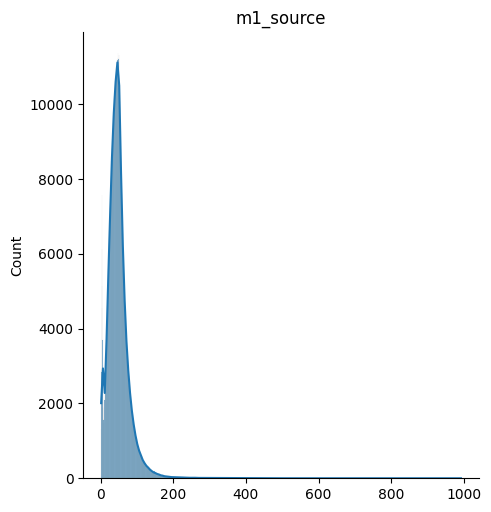

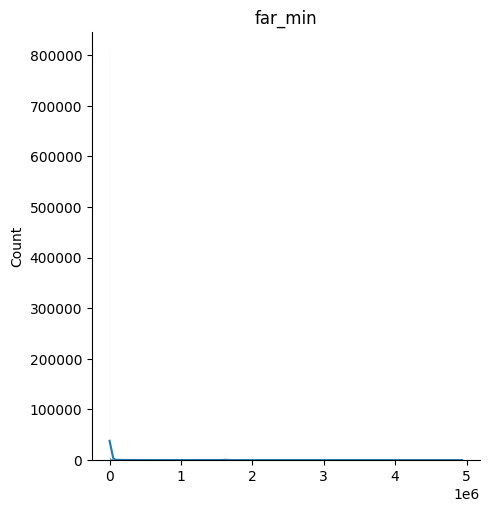

In [156]:
for i in range(dataset.X_data.whitened_data.shape[1]):
    # continue
    sns.displot(np.array(dataset.X[:, i]), kde=True)
    plt.title(dataset.X_data.data_df.columns[i])
    plt.show()

### Build Flowjax MAF

In [157]:
key_val = 0
key = jax.random.key(key_val)
train_dataset, val_dataset, train_idx, val_idx = dataset.split(key, train_frac=0.9)

config_MAF = {
    "base_dist": "Normal",
    "data_dim": train_dataset.X.shape[1],
    "key": key_val,
    # "cond_dim": train_dataset.y.shape[1],  
    "flow_layers": 6,
    "nn_width": 96,
    "nn_depth": 4
}

config = config_MAF
config["type"] = "MAF"

flow = ut.create_flow_from_config(config)

In [158]:
flow, meta = ut.train_flow(flow, train_dataset, val_dataset, patience = 25, batch_size = 4096)

Training:   3%|▎         | 27/1000 [00:32<19:13,  1.19s/it, best_val=12.2613, patience=-1, train=14.1497, val=13.8899]                       


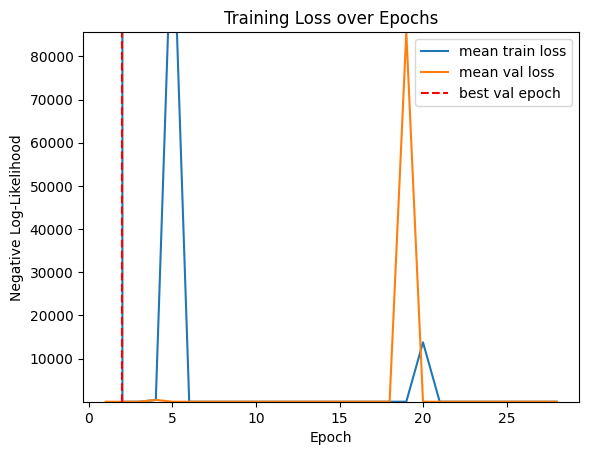

In [159]:
train_losses = meta["train_losses"]
val_losses = meta["val_losses"]

sns.lineplot(x=np.arange(1, len(train_losses) + 1), y=train_losses, label = "mean train loss")
sns.lineplot(x=np.arange(1, len(val_losses) + 1), y=val_losses, label = "mean val loss")
plt.vlines(x = meta["best_epoch"], ymin = min(val_losses)-1, ymax = max(val_losses), color = "red", linestyle = "--", label = "best val epoch")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
# plt.yscale("log")
plt.ylim(min(val_losses + train_losses)-.1, max(val_losses))
plt.show()

In [171]:
key, subkey = jax.random.split(key)
z_samples = np.array(flow.sample(subkey, (len(val_dataset),)))
z_samples_real_space, _ = dataset.to_original_space(z_samples)

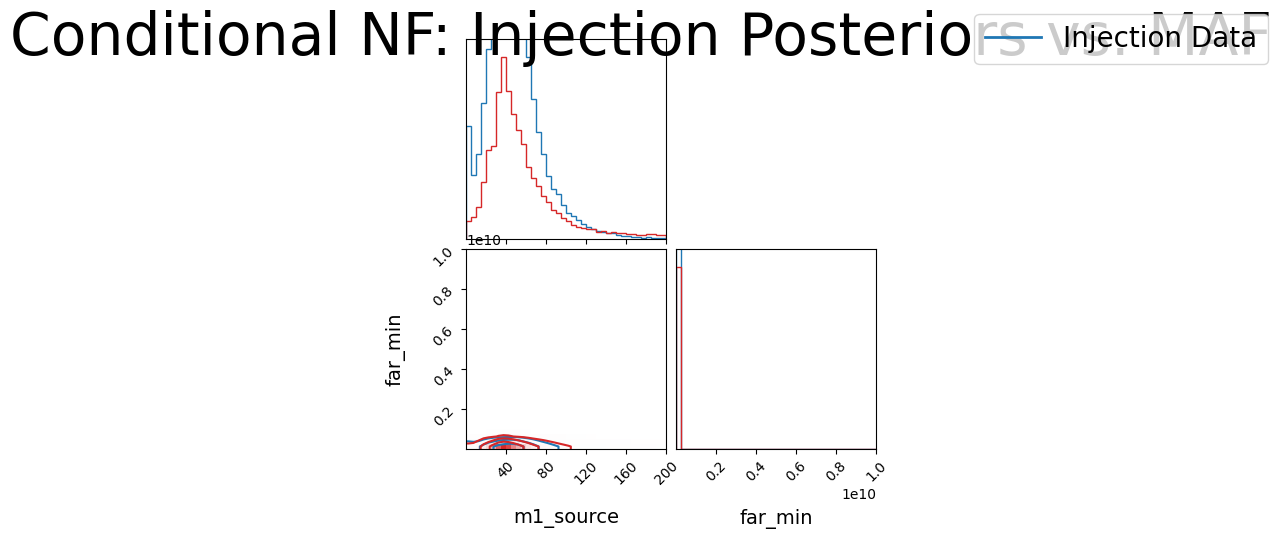

In [172]:
# labels = [r"$m_{1,\rm det}$", r"$m_{2,\rm det}$", r"$D_L$", r"$\chi_\mathrm{eff}$", r"$\alpha$", r"$\delta$"]
ranges = [(0, 200), (1e-60, 1e10)]
# ranges = [(0, 1)]
# data_cols = ["m1_detector", "m2_detector", "luminosity_distance", "a1", "a2", "cos_inclination", "polarization", "cost1", "cost2", "right_ascension", "declination"]

labels = X_data.data_df.columns

data_samples = val_dataset.X_data.data_df.iloc[val_idx]

fig = corner.corner(
    data_samples,
    labels=labels,
    color="C0",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    label_kwargs={"fontsize": 14},
    range = ranges,
)

corner.corner(
    np.array(z_samples_real_space),
    fig=fig,
    color="C3",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    range = ranges,
)


legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label=f"Injection Data"),
    # Line2D([0], [0], color="C3", lw=2, label="Conditional (FAR < 1) NF samples"),
    # Line2D([0], [0], color="none", lw=0, label=f"{np.sum(data_sel)} samples each"),
]

fig.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=20,
    frameon=True,
    handlelength = 2,
)

plt.suptitle("Conditional NF: Injection Posteriors vs. MAF", fontsize=42)
# plt.savefig("plots/CNF_InjectionsVSMAF_1FAR.pdf")
plt.show()

In [16]:
filename_flow = "trained_flows/CNF_Injections/CNF.npz"

In [39]:
# config["trained_columns"] = train_dataset.X_data.data_df.columns.to_list()
# ut.save_flow(filename_flow, flow, config)
# also need to save the data (transformations)
# train_dataset.save("trained_flows/CNF_Injections/training_dataset/", save_data = True)
# val_dataset.save("trained_flows/CNF_Injections/val_dataset/", save_data = True)
# dataset.save("trained_flows/CNF_Injections/dataset/", save_data = True)
# X_data.save("trained_flows/CNF_Injections/X")
# y_data.save("trained_flows/CNF_Injections/y")

Data and transformations saved to trained_flows/CNF_Injections/dataset/X
Data and transformations saved to trained_flows/CNF_Injections/dataset/y
Dataset configuration saved to trained_flows/CNF_Injections/dataset


### Quantitative Evaluation: Summary Statistics

Let's compare the descriptive statistics (mean, standard deviation, and correlations) of the original samples and the flow-generated samples. A good fit should show similar statistics between the two sets.

In [173]:
import pandas as pd

# Convert to pandas DataFrames for easy summary statistics
df_samples = dataset.X_data.data_df
df_rec = pd.DataFrame(x_rec, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_rec.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_rec.corr())

--- Original Samples Summary Statistics ---


,m1_source,far_min
count,973850.000000,9.738500e+05
mean,48.675684,8.463900e+04
std,31.084040,3.541874e+05
min,1.001118,1.223480e-66
25%,31.068344,4.655930e-06
50%,44.923459,1.376934e+00
75%,59.494014,4.081108e+02
max,992.547345,4.941142e+06



--- Flow-Generated Samples Summary Statistics ---


,m1_source,far_min
count,973850.000000,9.738500e+05
mean,48.675684,8.463900e+04
std,31.084040,3.541874e+05
min,1.001118,-2.419964e-02
25%,31.068344,1.542193e-03
50%,44.923459,1.376905e+00
75%,59.494014,4.081101e+02
max,992.547355,4.941142e+06



--- Original Samples Correlation Matrix ---


,m1_source,far_min
m1_source,1.000000,0.055343
far_min,0.055343,1.000000



--- Flow-Generated Samples Correlation Matrix ---


,m1_source,far_min
m1_source,1.000000,0.055343
far_min,0.055343,1.000000


### Quantitative Evaluation: Kolmogorov-Smirnov (KS) Test

The Kolmogorov-Smirnov test is a non-parametric test that compares the empirical cumulative distribution functions (ECDFs) of two samples. We'll perform it for each 1D marginal distribution to check if the original and flow-generated samples come from the same underlying distribution. A small p-value (e.g., < 0.05) would suggest that the distributions are statistically significantly different.

In [174]:
from scipy import stats

print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")
dowsample = 1
for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(data_samples.to_numpy()[::dowsample, i]), x_rec[::dowsample, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: m1_source
  KS Statistic: 0.0018
  P-value: 0.9485
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: far_min
  KS Statistic: 0.1645
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)


In [175]:
# Assumed constants
H0cosmo = 67.9 # constants from https://dcc.ligo.org/public/0170/P2000318/011/o3b_catalog.pdf
Om0cosmo = 0.3065
cosmo = FlatLambdaCDM(H0=H0cosmo * u.km / u.s / u.Mpc, Om0=Om0cosmo)
speed_of_light = constants.c.to(u.km / u.s).value

def ddL_of_z(z, dL, H0):
    return dL / (1 + z) + speed_of_light * (1 + z) / (H0 * cosmo.efunc(z))

N_eval = 1000000
mass_grid = np.linspace(1, 1000, N_eval)
spin_grid = np.linspace(0, 1, N_eval)
z_grid = np.linspace(0, 3, N_eval)
dVdz_grid = cosmo.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value * 4 * np.pi

def primary_mass_pdf_interp(m1, min_m1=1.0, max_m1=1000.0):

    m = mass_grid.astype(float)
    logm = np.log(m)

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definitions in log-space ---
    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50): continuity enforced explicitly
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - 1.0 * (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - 1.0 * (logm[sel] - np.log(200.0))

    # Outside allowed range
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- normalize robustly ---
    norm = np.trapezoid(pdf, m)
    if norm > 0:
        pdf /= norm

    # --- interpolate ---
    return interp1d(
        m, pdf,
        bounds_error=False,
        fill_value=0.0,
        assume_sorted=True
    )(m1)

def primary_mass_pdf(m1, min_m1=1.0, max_m1=1000.0):

    m = np.asarray(m1, dtype=float)
    logm = np.log(m, where=(m > 0), out=np.full_like(m, -np.inf))

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definition in log-space ---

    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50)
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(200.0))

    # Outside bounds
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- robust normalization ---
    # Sort for trapezoid stability
    idx = np.argsort(m)
    m_sorted = m[idx]
    pdf_sorted = pdf[idx]

    norm = np.trapezoid(pdf_sorted, m_sorted)
    if norm > 0:
        pdf /= norm

    return pdf


def secondary_mass_pdf(m2, m1, min_m2 = 1):

    pm2 = 2*m2 / (m1**2 - 1)
    support = (m2 >= min_m2) & (m2 <= m1)
    # should be properly normalized already I realize
    return np.where(support, pm2, 0.0)

def spin_pdf(s):

    ps = np.exp(-2*s**2)

    idx = np.argsort(s)
    s_sorted = s[idx]
    pdf_sorted = ps[idx]
    
    norm = np.trapezoid(pdf_sorted, s_sorted)
    if norm > 0:
        ps /= norm

    return ps

def cos_tilts_pdf(tilt):
    """Includes Jacobian to go from tilt to cos_tilt"""
    cos_tilt = np.cos(tilt)
    # should be normalized given the definition
    pcost = (0.3 * ((1+cos_tilt)**3)/4 + 0.35)*np.sin(tilt)  # last summand is 0.7*1/2
    return pcost

def tilts_pdf(tilt):
    # should be normalized given the definition
    pcost = (0.3 * ((1+tilt)**3)/4 + 0.35)  # last summand is 0.7*1/2
    return pcost

def redshift_pdf(z, z_grid, dVdz_grid):
    num_grid = dVdz_grid
    den = np.trapezoid(num_grid, z_grid)
    num_grid /= den
    
    return interp1d(z_grid, num_grid, fill_value = 0, bounds_error = False)(z)

In [176]:
def calc_p_model(data: pd.DataFrame, redshifts: np.ndarray |None = None) -> np.ndarray:
    """Calculates the p(theta) for GWTC and specific 13 parameters

    Args:
        data: DataFrame containing the parameters.

    Returns:
        Model probabilites.
    """

    pm1 = primary_mass_pdf(data["m1_source"])
    pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])
    pa1 = spin_pdf(data["a1"].to_numpy())
    pa2 = spin_pdf(data["a2"].to_numpy())
    pt1 = cos_tilts_pdf(data["t1"])
    pt2 = cos_tilts_pdf(data["t2"])
    pz = redshift_pdf(data["redshift"], z_grid, dVdz_grid)

    # Make sure data is correctly drawn from the below pdfs (follows GWTC-4)

    pphi1 = np.ones_like(data["phi1"]) / (2*np.pi) # uniform in [0, 2pi]
    pphi2 = np.ones_like(data["phi2"]) / (2*np.pi) # uniform in [0, 2pi]
    pra = np.ones_like(data["right_ascension"]) / (2*np.pi) # uniform in [0, 2pi]
    ppol = np.ones_like(data["polarization"]) / np.pi # uniform in [0, pi]
    pdec = 1 / 2 # uniform in sin(delta) [-1, 1]
    pinc = 1 / 2 # uniform in cos(inc) [-1, 1]

    return pm1*pm2*pa1*pa2*pz*pt1*pt2*pphi1*pphi2*pra*pdec*ppol*pinc

def calc_p_model_masses(data: pd.DataFrame) -> np.ndarray:
    """Calculates the p(theta) for GWTC and specific 13 parameters

    Args:
        data: DataFrame containing the parameters.

    Returns:
        Model probabilites.
    """

    pm1 = primary_mass_pdf(data["m1_source"])
    pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])
    
    return pm1*pm2

In [177]:
from functools import partial
@partial(jax.jit, static_argnames=['transformations'])
def calc_jacobians_transform_cnf_jit(theta, transformations):
    """
    JAX-compatible calculation of Jacobian log-determinant.
    
    Args:
        theta: JAX array of shape (N,) containing parameters.
        transformations: Tuple or list of strings defining the transform for each param.
                         Must be marked static for JIT compilation.
    """
    # assert len(transformations) == 13, f"length of transformations is {len(transformations)} while it should be 13"

    log_j_sum = 0

    for i, transform in enumerate(transformations):
        param = theta[i]
        if transform == "log":
            term = (jnp.abs(1/param))
        elif transform == "angle_2pi":
            term = jnp.abs(1/param + 1/(2*jnp.pi - param))
        elif transform == "angle_pi":
            term = jnp.abs(1/param + 1/(jnp.pi - param))            
        elif transform == "angle_signed_pi":
            term = jnp.abs((2*jnp.pi) / (jnp.pi**2 - param**2))
        else:
            term = 1 # is 0 in log
        log_j = jnp.log(term)
        log_j_sum += log_j
    return log_j_sum

In [178]:
@eqx.filter_jit
def calc_log_prob(flow, batch):
    return flow.log_prob(batch)

In [184]:
def calc_p_detection_primary_mass_no_jacobian(flow: Transform, val_dataset: ut.Dataset, val_idx, redshifts: np.ndarray |None = None, far_threshold: float = 1) -> np.ndarray:

    # theta here is only the parameters of the event, not FAR!
    theta = jnp.array(val_dataset.X[:,:1].copy()) # make sure we work on the gw parameters only for the flow
    print(theta.shape)
    data = val_dataset.X_data.full_data_df.iloc[val_idx]

    theta_pre_transform = val_dataset.X_data.data_df[["m1_source"]].to_numpy()[val_idx].squeeze()
    
    print(f"Calculating model...")
    p_model = primary_mass_pdf(data["m1_source"])

    weights = data["weights"].to_numpy()
    assert len(weights) == len(theta), f"Wrong shapes: {weights.shape} and {theta.shape}"

    # for each parameter combination need to integrate out the FARs to the threshold
    far_threshold = 1
    far_grid_log = jnp.linspace(-12, np.log(far_threshold), 1000)
    far_grid = jnp.exp(far_grid_log)
    
    p_joint_no_J = []
    for t_i in tqdm(theta[:]):
        # assert t_i.shape == (2,)
        batch_inputs = jnp.column_stack([
            jnp.full_like(far_grid, t_i[0]),
            far_grid
        ])
        # print(batch_inputs.shape)
        log_prob = calc_log_prob(flow, batch_inputs)
        density = jnp.exp(log_prob) # this is all in whitened space
        integral_value = jnp.trapezoid(y=density, x=far_grid)
        
        p_joint_no_J.append(integral_value)

    p_joint_no_J = np.array(p_joint_no_J)
    p_joint = p_joint_no_J
    
    return p_model, p_joint

In [185]:
def calc_p_detection(flow: Transform, val_dataset: ut.Dataset, val_idx, redshifts: np.ndarray |None = None, far_threshold: float = 1) -> np.ndarray:

    # theta here is only the parameters of the event, not FAR!
    theta = jnp.array(val_dataset.X[:,:2].copy()) # make sure we work on the gw parameters only for the flow
    print(theta.shape)
    data = val_dataset.X_data.full_data_df.iloc[val_idx]

    theta_pre_transform = val_dataset.X_data.data_df[["m1_source", "m2_source"]].to_numpy()[val_idx].squeeze()
    
    print(f"Calculating model...")
    p_model = calc_p_model_masses(data)

    weights = data["weights"].to_numpy()
    assert len(weights) == len(theta), f"Wrong shapes: {weights.shape} and {theta.shape}"

    # for each parameter combination need to integrate out the FARs to the threshold
    L = val_dataset.X_data.L
    mu = val_dataset.X_data.mu
    far_threshold = 1
    x_far_thresh = jnp.log(far_threshold)

    # precompute jacobians
    log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(theta_pre_transform, tuple(val_dataset.X_data.transformations[:-1]))
    log_jacobian_whitening = jnp.sum(jnp.log(jnp.diag(val_dataset.X_data.L)[:2])) # only up to 2, because no FAR Jacobian!
    
    p_joint_no_J = []
    for t_i in tqdm(theta[:]):
        # assert t_i.shape == (2,)

        numerator = (x_far_thresh - mu[2]) - (L[2, 0] * t_i[0] + L[2, 1] * t_i[1])
        whitened_far_upper = numerator / L[2, 2]
        far_whitened_grid = jnp.linspace(-15, whitened_far_upper, 2000)
    
        batch_inputs = jnp.column_stack([
            jnp.full_like(far_whitened_grid, t_i[0]),
            jnp.full_like(far_whitened_grid, t_i[1]),
            far_whitened_grid
        ])
        # print(batch_inputs.shape)
        log_prob = calc_log_prob(flow, batch_inputs)
        density = jnp.exp(log_prob) # this is all in whitened space
        integral_value = jnp.trapezoid(y=density, x=far_whitened_grid)
        
        p_joint_no_J.append(integral_value)

    p_joint_no_J = np.array(p_joint_no_J)
    p_joint = p_joint_no_J * np.exp(log_jacobian_transformations) / np.exp(log_jacobian_whitening)
    
    return p_model, p_joint

In [186]:
val_dataset.X_data.transformations, jnp.diag(val_dataset.X_data.L)[:2]

(['none', 'none'], Array([3.1084040e+01, 3.5364461e+05], dtype=float64))

In [187]:
jnp.array(val_dataset.X.copy())[:,1].shape

(97385,)

In [188]:
# p_model, N, log_pCNFs, log_jacobian_transformations, log_jacobian_whitening = calc_p_detection(loaded_flow, val_dataset, val_idx)
p_model, p_joint = calc_p_detection_primary_mass_no_jacobian(flow, val_dataset, val_idx)

(97385, 1)
Calculating model...


100%|██████████| 97385/97385 [02:25<00:00, 671.33it/s]


In [189]:
p_joint.min(), p_joint.max()

(np.float64(2.127992857993293e-07), np.float64(0.0007034799944898975))

In [190]:
p_model.min(), p_model.max()

(np.float64(7.640789060250599e-07), np.float64(0.30385537577108523))

In [194]:
p_det = p_joint/p_model
p_det.min(), p_det.max()

(np.float64(2.560993018049645e-06), np.float64(653.1850418823171))

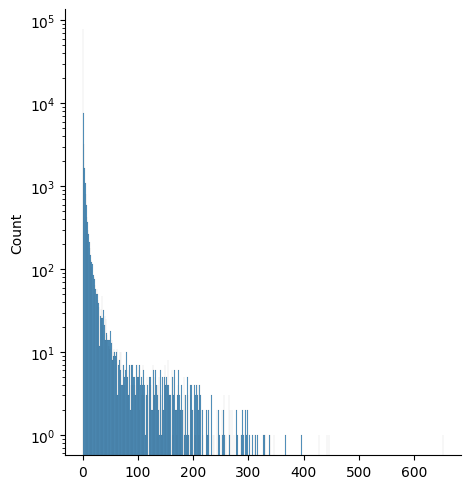

In [193]:
sns.displot()
plt.yscale("log")